In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
# What I did in each step is in comment.
# Imported libraries here

In [3]:
df= pd.read_csv("naqshab_javed_day.csv")
print(df.head())
#Read .csv file here

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  01-01-2018       1   0     1        0        1           1   
1        2  02-01-2018       1   0     1        0        2           1   
2        3  03-01-2018       1   0     1        0        3           1   
3        4  04-01-2018       1   0     1        0        4           1   
4        5  05-01-2018       1   0     1        0        5           1   

   weathersit       temp     atemp      hum  windspeed  casual  registered  \
0           2  14.110847  18.18125  80.5833  10.749882     331         654   
1           2  14.902598  17.68695  69.6087  16.652113     131         670   
2           1   8.050924   9.47025  43.7273  16.636703     120        1229   
3           1   8.200000  10.60610  59.0435  10.739832     108        1454   
4           1   9.305237  11.46350  43.6957  12.522300      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  


In [4]:
print(df.info())
# Got Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB
None


In [5]:
print(df.describe())
#Got More info

          instant      season          yr        mnth     holiday     weekday  \
count  730.000000  730.000000  730.000000  730.000000  730.000000  730.000000   
mean   365.500000    2.498630    0.500000    6.526027    0.028767    2.995890   
std    210.877136    1.110184    0.500343    3.450215    0.167266    2.000339   
min      1.000000    1.000000    0.000000    1.000000    0.000000    0.000000   
25%    183.250000    2.000000    0.000000    4.000000    0.000000    1.000000   
50%    365.500000    3.000000    0.500000    7.000000    0.000000    3.000000   
75%    547.750000    3.000000    1.000000   10.000000    0.000000    5.000000   
max    730.000000    4.000000    1.000000   12.000000    1.000000    6.000000   

       workingday  weathersit        temp       atemp         hum   windspeed  \
count  730.000000  730.000000  730.000000  730.000000  730.000000  730.000000   
mean     0.690411    1.394521   20.319259   23.726322   62.765175   12.763620   
std      0.462641    0.5448

In [6]:
df.count()
#Counted the total number of items in each row

instant       730
dteday        730
season        730
yr            730
mnth          730
holiday       730
weekday       730
workingday    730
weathersit    730
temp          730
atemp         730
hum           730
windspeed     730
casual        730
registered    730
cnt           730
dtype: int64

In [25]:
df.isnull().sum()
#Checked weather the data contains any null values or not 

instant         0
dteday          0
yr              0
mnth            0
holiday         0
workingday      0
temp            0
atemp           0
hum             0
windspeed       0
casual          0
registered      0
cnt             0
year            0
day             0
season_2        0
season_3        0
season_4        0
weathersit_2    0
weathersit_3    0
weekday_1       0
weekday_2       0
weekday_3       0
weekday_4       0
weekday_5       0
weekday_6       0
month_2         0
month_3         0
month_4         0
month_5         0
month_6         0
month_7         0
month_8         0
month_9         0
month_10        0
month_11        0
month_12        0
dtype: int64

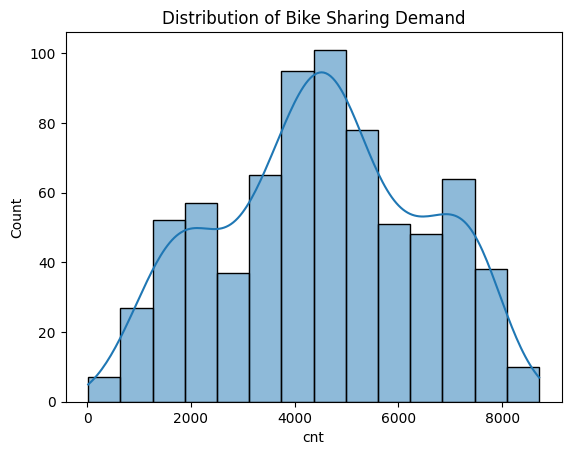

In [26]:
sns.histplot(df['cnt'], kde=True)
plt.title('Distribution of Bike Sharing Demand')
plt.show()
# Plotted a graph to understand the data 

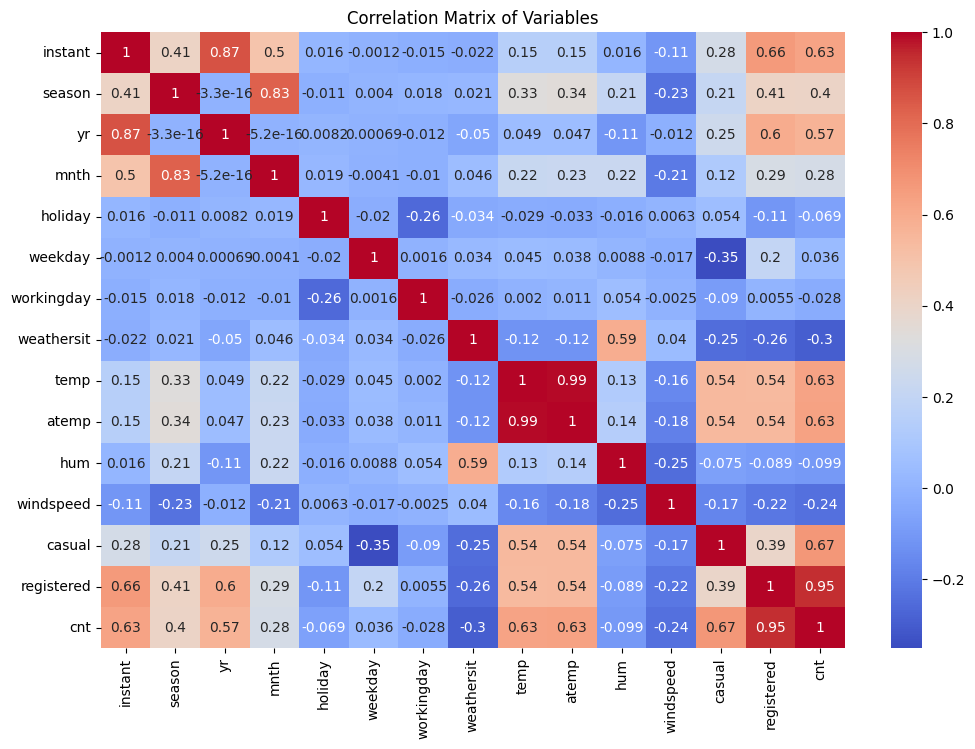

In [10]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Variables')
plt.show()
# Couldn't understand the date so used color distinction to 
# know how every other variable is dependent on cnt

In [11]:
date_column = 'dteday'
df[date_column] = pd.to_datetime(df[date_column], dayfirst=True)
df['year'] = df[date_column].dt.year
df['month'] = df[date_column].dt.month
df['day'] = df[date_column].dt.day
df['weekday'] = df[date_column].dt.dayofweek
print("Date column has been changed")
#converted the date column into form understood by machine for learning 


Date column has been changed


In [12]:
categorical_cols = ['season', 'weathersit', 'weekday', 'month']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Categorical columns has been changed through one hot encoding.")
# did One hot encoding

Categorical columns has been changed through one hot encoding.


In [13]:
columns_to_drop = [date_column, 'casual', 'registered', 'atemp']
df_processed = df.drop(columns=columns_to_drop, axis=1)
print("bogus columns have been dropped")
print(df_processed.head())
df_processed.info()
#dropped date row as its data has been stored seprately
#casual and registered as cnt is a summation of these two
# a temp as it is very similar to temp, hence can be dropped

bogus columns have been dropped
   instant  yr  mnth  holiday  workingday       temp      hum  windspeed  \
0        1   0     1        0           1  14.110847  80.5833  10.749882   
1        2   0     1        0           1  14.902598  69.6087  16.652113   
2        3   0     1        0           1   8.050924  43.7273  16.636703   
3        4   0     1        0           1   8.200000  59.0435  10.739832   
4        5   0     1        0           1   9.305237  43.6957  12.522300   

    cnt  year  ...  month_3  month_4  month_5  month_6  month_7  month_8  \
0   985  2018  ...    False    False    False    False    False    False   
1   801  2018  ...    False    False    False    False    False    False   
2  1349  2018  ...    False    False    False    False    False    False   
3  1562  2018  ...    False    False    False    False    False    False   
4  1600  2018  ...    False    False    False    False    False    False   

   month_9  month_10  month_11  month_12  
0    False 

In [20]:
X = df_processed.drop('cnt', axis=1) 
y = df_processed['cnt']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
#trained the model here


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
print("Model trained successfully")


Model trained successfully


In [22]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coefficients = coefficients.reindex(coefficients.Coefficient.abs().sort_values(ascending=False).index)

print("--- Significant Variables ---")
print(coefficients)

# To check for the variables that are significant in the demand for shared bikes with
#the available independent variables stored as coefficients.

--- Significant Variables ---
              Coefficient
weathersit_3 -2099.465000
season_4      1724.285271
season_2      1099.834407
season_3      1001.039678
holiday       -900.745361
month_9        623.146902
month_3        498.600456
month_11      -495.275856
weathersit_2  -463.396860
month_12      -416.065061
month_5        401.271181
workingday    -352.207022
weekday_3      324.322424
weekday_4      289.132768
month_7       -284.946102
month_10       239.296036
month_4        174.973499
mnth          -145.350559
weekday_2      144.134487
month_6        137.898699
temp           111.698518
weekday_5      -92.414450
month_2         91.517735
weekday_6       47.065109
windspeed      -42.648434
weekday_1       33.199870
yr              16.375767
year            16.375767
hum            -13.623556
day            -12.510228
month_8          6.677625
instant          5.318193

Top 3 Most Significant Variables:
              Coefficient
weathersit_3 -2099.465000
season_4      1724.285271

In [23]:
print("\nTop 3 Most Significant Variables:")
print(coefficients.head(3))


Top 3 Most Significant Variables:
              Coefficient
weathersit_3 -2099.465000
season_4      1724.285271
season_2      1099.834407


In [24]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n--- Model Evaluation ---")
print(f"R-squared (R^2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
#model evaluaton: the high the R^2 value the better the model
# the lower the MAE value the better the model


--- Model Evaluation ---
R-squared (R²): 0.8593
Mean Absolute Error (MAE): 534.8601
